## 数据加载、可视化与线性回归

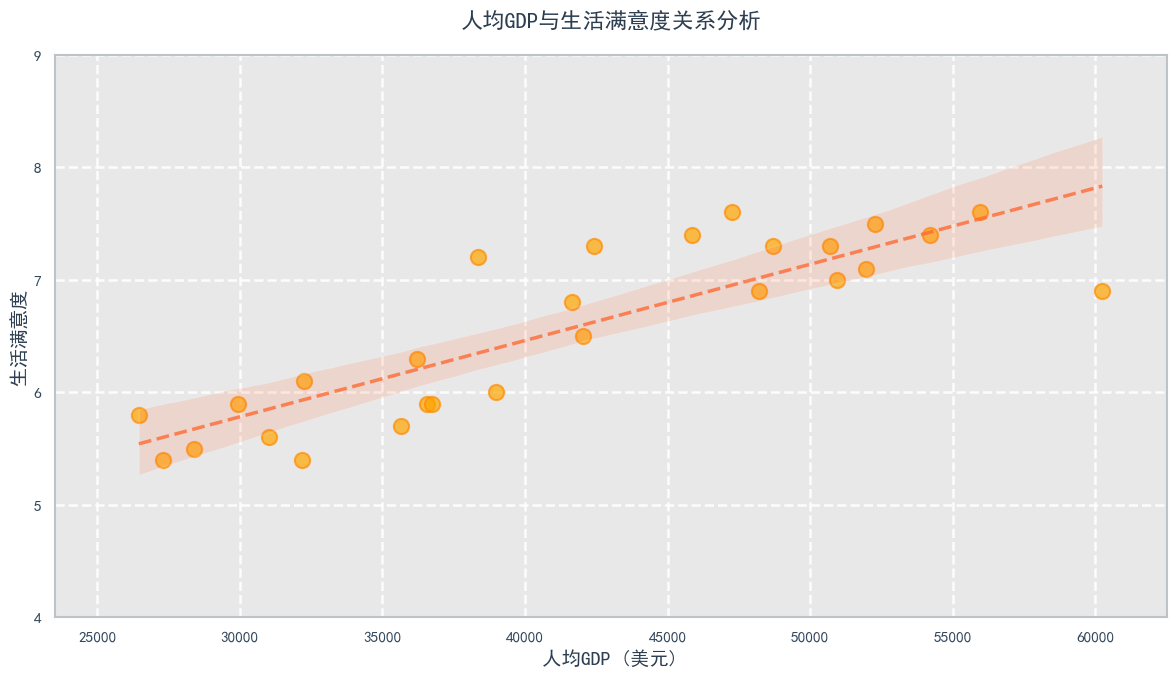

预测结果: 6.30


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression  # 导入线性回归

# 设置 Seaborn 样式
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
sns.set_palette("husl")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 解决负号问题

lifesat = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# 可视化数据 - 使用seaborn美化
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('#E8E8E8')  # 设置坐标轴背景为浅灰色

# 使用seaborn 绘制散点图和回归线
sns.regplot(x=lifesat["GDP per capita (USD)"],
            y=lifesat["Life satisfaction"],
            scatter_kws={
                'color': 'orange',
                's': 120,  # 散点大小
                'alpha': 0.7,
                'edgecolor': 'darkorange',
                'linewidths': 1.5
            },
            line_kws={
                'color': '#FF6B35',  # 回归线颜色
                'linewidth': 2.5,
                'linestyle': '--',
                'alpha': 0.8
            },
            ci=95,   # 95% 置信区间
            ax=ax)

# 设置中文标签
ax.set_xlabel('人均GDP (美元)', fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_ylabel('生活满意度', fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_title('人均GDP与生活满意度关系分析', fontsize=16, fontweight='bold',
             color='#2C3E50', pad=20)

# 设置白色虚线网格
ax.grid(True, color='white', linestyle='--', linewidth=1.8, alpha=0.9)

# 设置坐标轴范围
ax.set_xlim(23_500, 62_500)
ax.set_ylim(4, 9)

# 美化坐标轴刻度
ax.tick_params(axis='both', which='major', labelsize=11, colors='#34495E')

# 添加边框样式
for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

# 选择线性模型（导入算法，不是创建模型！）
model = LinearRegression()

# 训练模型
model.fit(X, y)  # 真正训练，可以训练完成后进行保存，由于此时的项目比较简单，不用跑轮数，就能解决，这种模型较小，没有保存的意义

# 为塞浦路斯做预测
X_new = [[37_655.2]]  # 塞浦路斯2020年人均GDP
prediction = model.predict(X_new)     # 预测模型
print(f"预测结果: {prediction[0][0]:.2f}")  # 输出中文提示

## K近邻回归模型 (KNN)

In [4]:
# [9]: # 选择一个 3 近邻回归模型
from sklearn.neighbors import KNeighborsRegressor  # K近邻线性回归模型

model_knn = KNeighborsRegressor(n_neighbors=3)  # 取3个邻居做样本
# 这里将一个故事：在欧洲某个小镇，来了一个外乡人，这个外乡人是黑头发，黑眼睛，但是欧洲群众投票认为他就是同一个若种，那么分类上他
# 就属于这个小镇

# 训练模型
model_knn.fit(X, y)

# 为塞浦路斯做预测
prediction_knn = model_knn.predict(X_new)
print(f"K近邻回归预测结果: {prediction_knn[0][0]:.2f}") # 输出 [[6.33333333]]

K近邻回归预测结果: 6.33


In [9]:
# [12]:
oecd_bli = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\oecd_bli.csv")  # 读取OECD生活满意度数据
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"] # 获取总计数据，排除分群组(分维度)
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
oecd_bli.head()

# [14]:
gdp_per_capita = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\gdp_per_capita.csv", delimiter='\t', encoding='latin1', na_values="n/a")
gdp_per_capita.rename(columns={"2020": "GDP per capita (USD)"}, inplace=True)
gdp_per_capita.set_index("Country", inplace=True)
gdp_per_capita.head()

KeyError: "None of ['Country'] are in the columns"

In [ ]:
# left: 左表 (OECD生活满意度数据)
# right: 右表 (人均GDP数据)
# left_index=True, right_index=True 以两表的索引(均为国家名)作为连接键
full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                              left_index=True, right_index=True)
full_country_stats.sort_values(by="GDP per capita (USD)", inplace=True)
remove_indices = [0, 1, 6, 8, 33, 34, 35]
keep_indices = list(set(range(36)) - set(remove_indices))

# 这里的逻辑似乎在原代码中被简化了，图片中直接展示了根据GDP筛选
# 下面是图片中展示的筛选逻辑：
full_country_stats = full_country_stats[["GDP per capita (USD)", "Life satisfaction"]]

full_country_stats.head()
# 为了说明过拟合的风险，在大部分图表中只使用了部分数据 (即人均GDP处于min_gdp和max_gdp之间的国家)
# 被移除的国家是那些可能会对模型产生干扰的离群点
min_gdp = 23_500
max_gdp = 62_500

country_stats = full_country_stats[(full_country_stats["GDP per capita (USD)"] >= min_gdp) &
                                   (full_country_stats["GDP per capita (USD)"] <= max_gdp)]
country_stats.head()

In [ ]:
# [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义图片保存函数
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join("images", fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 准备数据
sample_data = full_country_stats[["GDP per capita (USD)", "Life satisfaction"]]
sample_data.plot(kind='scatter', x="GDP per capita (USD)", y="Life satisfaction", figsize=(5,3))
plt.axis([0, 60000, 0, 10])

# 定义要坐标标注的国家及其中文位置
position_text = {
    "Hungary": (5000, 1),
    "Korea": (18000, 1.7),
    "France": (29000, 2.4),
    "Australia": (40000, 3.0),
    "United States": (52000, 3.8),
}

# 绘制散点图并标注
for country, pos_text in position_text.items():
    pos_data_x, pos_data_y = sample_data.loc[country]
    country = "U.S." if country == "United States" else country
    plt.annotate(country, xy=(pos_data_x, pos_data_y), xytext=pos_text,
            arrowprops=dict(facecolor='black', width=0.5, shrink=0.1, headwidth=5))
    plt.plot(pos_data_x, pos_data_y, "ro")

plt.xlabel("GDP per capita (USD)")
plt.show()

In [ ]:
# [28]:
import matplotlib.pyplot as plt
import numpy as np

# ... (省略重复的设置部分) ...

# 模型参数调整演示
lin1 = np.linspace(0, 60000, 1000)
plt.plot(sample_data["GDP per capita (USD)"], sample_data["Life satisfaction"], "bo")

theta0 = 4.85
theta1 = 4.91e-5
plt.plot(lin1, theta0 + theta1 * lin1, "b")

theta0 = 8
theta1 = -5e-5
plt.plot(lin1, theta0 + theta1 * lin1, "g")

theta0 = 0
theta1 = 2e-4
plt.plot(lin1, theta0 + theta1 * lin1, "r")

plt.axis([0, 60000, 0, 10])
plt.show()

In [ ]:
# [32]:
from sklearn import linear_model

lin1 = linear_model.LinearRegression()
Xsample = np.c_[sample_data["GDP per capita (USD)"]]
ysample = np.c_[sample_data["Life satisfaction"]]

lin1.fit(Xsample, ysample)

t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

print(f"截距 (theta0): {t0}")
print(f"斜率 (theta1): {t1}")

# 绘制最佳拟合线
plt.plot(sample_data["GDP per capita (USD)"], sample_data["Life satisfaction"], "bo")
plt.plot(Xsample, t0 + t1 * Xsample, "b")
plt.axis([0, 60000, 0, 10])
plt.show()

In [ ]:
cyprus_gdp_per_capita = gdp_per_capita.loc["Cyprus"]["GDP per capita (USD)"]
print(cyprus_gdp_per_capita)
# 输出: 37655.1803457421

# [41]:
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0][0]
print(cyprus_predicted_life_satisfaction)
# 输出: 6.301657...

# [45]: 绘图展示预测结果
sample_data.plot(kind='scatter', x="GDP per capita (USD)", y="Life satisfaction", figsize=(5,3), s=1)
X=np.linspace(0, 60000, 1000)
plt.plot(X, t0 + t1*X, "b")
plt.axis([0, 60000, 0, 10])
plt.text(5000, 7.5, r"$\theta_0 = 4.85$", fontsize=14, color="b")
plt.text(5000, 6.6, r"$\theta_1 = 4.91 \times 10^{-5}$", fontsize=14, color="b")

plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita], [0, cyprus_predicted_life_satisfaction], "r--")
plt.text(25000, 5.0, r"Prediction = 6.30", fontsize=14, color="b")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")
plt.show()

完整数据偏差分析：训练数据代表性研究

1. 读取训练数据...
   训练集包含 27 个国家

2. 读取完整数据集...
   完整数据集包含 36 个国家

3. 训练原始线性回归模型（使用训练集）...
   原始模型参数: theta0=3.75, theta1=6.78e-05
   训练数据GDP范围: $26456 - $60236

4. 识别超出训练范围的国家...
   找到 9 个国家超出训练范围

5. 开始绘制对比图表...
   - 添加国家标注...
    警告：数据中未找到国家 'Iceland'
   - 绘制原始模型预测线（蓝色虚线）...
   - 训练完整数据集模型（使用full的数据）...
   完整模型参数: theta0=5.58, theta1=2.33e-05
   - 绘制完整模型预测线（黑色实线）...
保存图片: representative_training_data_scatterplot


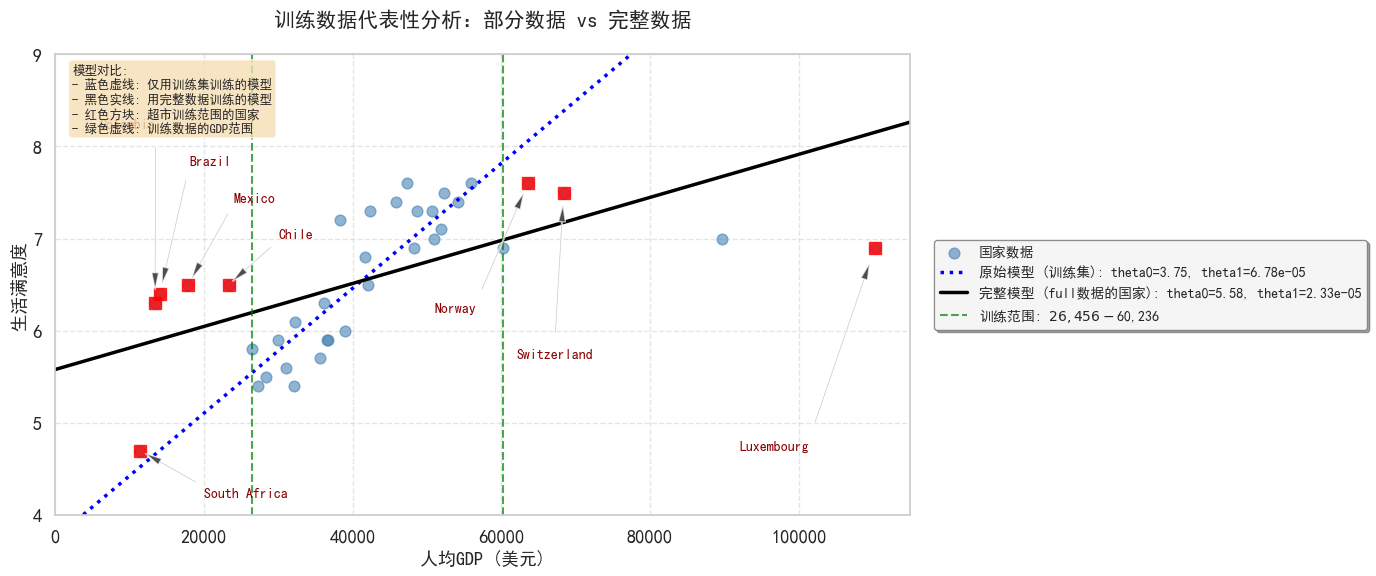


分析结果总结

训练集统计:
  - 国家数量: 27
  - GDP范围: $26,456 - $60,236
  - 模型参数: theta0=3.75, theta1=6.78e-05

完整数据集统计:
  - 国家数量: 36
  - GDP范围: $11,466 - $110,261
  - 模型参数: theta0=5.58, theta1=2.33e-05

#参数差异#
  - Delta_theta0 = 1.83 (48.8%)
  - Delta_theta1 = 4.44e-05 (65.6%)

超出训练范围的国家: 9

详细列表:
  - South Africa        : GDP=$11,466, 满意度=4.7 (低于训练范围)
  - Colombia            : GDP=$13,441, 满意度=6.3 (低于训练范围)
  - Brazil              : GDP=$14,064, 满意度=6.4 (低于训练范围)
  - Mexico              : GDP=$17,888, 满意度=6.5 (低于训练范围)
  - Chile               : GDP=$23,325, 满意度=6.5 (低于训练范围)
  - Norway              : GDP=$63,586, 满意度=7.6 (高于训练范围)
  - Switzerland         : GDP=$68,393, 满意度=7.5 (高于训练范围)
  - Ireland             : GDP=$89,689, 满意度=7.0 (高于训练范围)
  - Luxembourg          : GDP=$110,261, 满意度=6.9 (高于训练范围)

结论: 
  训练数据的代表性直接影响模型的泛化能力
  对于超出训练范围的数据，模型预测可能不准确（外推风险）。


In [10]:
import matplotlib.pyplot as plt  # 修正导入：通常用 pyplot
import matplotlib.pylab as pylab
import numpy as np
import pandas as pd
import os
from sklearn import linear_model

# 设置中文字体 (根据你的系统环境，可能需要调整 SimHei 为其他支持中文的字体，如 MS YaHei)
plt.rcParams['font.sans-serif'] = ["SimHei"]  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 解决负号问题

# 定义图片保存函数
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """保留图片 images 文件夹"""
    path = os.path.join("images", fig_id + "." + fig_extension)
    # 创建 images 文件夹（如果不存在）
    os.makedirs("images", exist_ok=True)
    print(f"保存图片: {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

print("=" * 70)
print("完整数据偏差分析：训练数据代表性研究")
print("=" * 70)

# 定义列名
gdppc_col = "GDP per capita (USD)"  # 人均GDP列名
lifesat_col = "Life satisfaction"   # 生活满意度

# 设置坐标轴范围
min_life_sat = 4      # 最小生活满意度
max_life_sat = 9      # 最大生活满意度

# 读取训练集数据（部分国家）
print("\n1. 读取训练数据...")
try:
    country_stats = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\lifesat.csv", index_col=0)
    print(f"   训练集包含 {len(country_stats)} 个国家")
except FileNotFoundError:
    print("错误：未找到 lifesat.csv 文件")
    country_stats = pd.DataFrame() # 防止后续报错

# 读取完整数据集（所有国家）
print("\n2. 读取完整数据集...")
try:
    full_country_stats = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\lifesat_full.csv", index_col=0)
    print(f"   完整数据集包含 {len(full_country_stats)} 个国家")
except FileNotFoundError:
    print("   警告：未找到lifesat_full.csv，使用训练集代替")
    full_country_stats = country_stats.copy()

# 训练原始模型（仅使用部分数据）
print("\n3. 训练原始线性回归模型（使用训练集）...")
if not country_stats.empty:
    X_sample = country_stats[[gdppc_col]].values  # 训练集特征
    y_sample = country_stats[[lifesat_col]].values  # 训练集目标值

    lin1 = linear_model.LinearRegression()  # 创建线性回归模型
    lin1.fit(X_sample, y_sample)  # 训练模型

    # 提取原始模型参数
    t0, t1 = lin1.intercept_[0], lin1.coef_.ravel()[0]
    print(f"   原始模型参数: theta0={t0:.2f}, theta1={t1:.2e}")

    # 计算训练数据的GDP范围
    min_gdp = country_stats[gdppc_col].min()   # 训练集最小GDP
    max_gdp = country_stats[gdppc_col].max()   # 训练集最大GDP
    print(f"   训练数据GDP范围: ${min_gdp:.0f} - ${max_gdp:.0f}")

    # 找出超出训练范围的国家
    print("\n4. 识别超出训练范围的国家...")
    missing_data = full_country_stats[(full_country_stats[gdppc_col] < min_gdp) | 
                                      (full_country_stats[gdppc_col] > max_gdp)]
    print(f"   找到 {len(missing_data)} 个国家超出训练范围")

    # 定义需要标注的国家及其文本显示位置
    # 字典格式："国家名": (文字X坐标, 文字Y坐标)
    position_text_missing_countries = {
        "South Africa": (20_000, 4.2),       # 南非
        "Colombia": (6_000, 8.2),            # 哥伦比亚
        "Brazil": (18_000, 7.8),             # 巴西
        "Mexico": (24_000, 7.4),             # 墨西哥
        "Chile": (30_000, 7.0),              # 智利
        "Norway": (51_000, 6.2),             # 挪威
        "Switzerland": (62_000, 5.7),        # 瑞士 (修正拼写)
        "Iceland": (81_000, 5.2),            # 冰岛/爱尔兰 (修正拼写)
        "Luxembourg": (92_000, 4.7),         # 卢森堡
    }

    print("\n5. 开始绘制对比图表...")

    # 创建图表
    fig, ax = plt.subplots(figsize=(14, 6))

    # 绘制完整数据集的散点图（国家）
    full_country_stats.plot(kind="scatter", 
                            x=gdppc_col, 
                            y=lifesat_col, 
                            grid=True,
                            color='steelblue',
                            s=60,
                            alpha=0.6,
                            ax=ax,
                            label="国家数据")

    # 为超出范围的特定国家添加标注
    print("   - 添加国家标注...")
    for country, pos_text in position_text_missing_countries.items():
        try:
            # 获取该国家的实际数据位置
            pos_data_x = missing_data.loc[country, gdppc_col]
            pos_data_y = missing_data.loc[country, lifesat_col]
            
            # 添加箭头和文本标注
            ax.annotate(country, 
                xy=(pos_data_x, pos_data_y), # 箭头指向的数据点的位置
                xytext=pos_text,             # 文本显示位置
                fontsize=10,
                fontweight='bold',
                color='darkred',
                arrowprops=dict(facecolor='black', 
                                width=0.5, 
                                shrink=0.08, 
                                headwidth=5, 
                                alpha=0.7))
            
            # 用红色方块标记这些国家
            ax.plot(pos_data_x, pos_data_y, "rs", markersize=8, alpha=0.8)
        except KeyError:
            print(f"    警告：数据中未找到国家 '{country}'")

    # 绘制原始模型的预测线（蓝色虚线，基于训练集）
    print("   - 绘制原始模型预测线（蓝色虚线）...")
    X_line = np.linspace(0, 115_000, 1000)  # 生成X轴数据点
    y_original = t0 + t1 * X_line   # 使用原始模型参数计算Y值
    ax.plot(X_line, y_original, "b:", linewidth=2.5, 
            label=f'原始模型 (训练集): theta0={t0:.2f}, theta1={t1:.2e}')

    # 使用完整数据集训练新模型
    print("   - 训练完整数据集模型（使用full的数据）...")
    lin_reg_full = linear_model.LinearRegression()    # 创建新的新型回归模型
    Xfull = np.c_[full_country_stats[gdppc_col]]      # 完整数据集特征
    yfull = np.c_[full_country_stats[lifesat_col]]    # 完整数据集目标值
    lin_reg_full.fit(Xfull, yfull)      # 训练完整模型

    # 提取完整模型参数
    t0full, t1full = lin_reg_full.intercept_[0], lin_reg_full.coef_.ravel()[0]
    print(f"   完整模型参数: theta0={t0full:.2f}, theta1={t1full:.2e}")

    # 绘制完整模型的预测线（黑色实线）
    print("   - 绘制完整模型预测线（黑色实线）...")
    y_full = t0full + t1full * X_line   # 使用完整模型参数计算Y值
    ax.plot(X_line, y_full, "k-", linewidth=2.5, 
            label=f'完整模型 (full数据的国家): theta0={t0full:.2f}, theta1={t1full:.2e}')

    # 标记训练数据的范围（添加垂直虚线）
    ax.axvline(x=min_gdp, color='green', linestyle='--', linewidth=1.5,
               alpha=0.7, label=f"训练范围: ${min_gdp:,.0f} - ${max_gdp:,.0f}")
    ax.axvline(x=max_gdp, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

    # 设置坐标轴范围
    ax.set_xlim(0, 115_000)
    ax.set_ylim(min_life_sat, max_life_sat)

    # 设置中文标签
    ax.set_xlabel('人均GDP (美元)', fontsize=13, fontweight='bold')
    ax.set_ylabel('生活满意度', fontsize=13, fontweight='bold')
    ax.set_title('训练数据代表性分析：部分数据 vs 完整数据', 
                 fontsize=15, fontweight='bold', pad=20)

    # 美化网格
    ax.grid(True, linestyle='--', alpha=0.5)

    # 添加图例
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, 
              framealpha=0.9, edgecolor='gray', fancybox=True, shadow=True)

    # 添加说明文本框
    textstr = "模型对比:\n" \
            "- 蓝色虚线: 仅用训练集训练的模型\n" \
            "- 黑色实线: 用完整数据训练的模型\n" \
            "- 红色方块: 超市训练范围的国家\n" \
            "- 绿色虚线: 训练数据的GDP范围"
            
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)

    # 保存图片
    save_fig('representative_training_data_scatterplot')

    # 显示图表
    plt.tight_layout()
    plt.show()

    # 输出分析结果
    print("\n" + "=" * 70)
    print("分析结果总结")
    print("=" * 70)
    print(f"\n训练集统计:")
    print(f"  - 国家数量: {len(country_stats)}")
    print(f"  - GDP范围: ${min_gdp:,.0f} - ${max_gdp:,.0f}")
    print(f"  - 模型参数: theta0={t0:.2f}, theta1={t1:.2e}")

    print(f"\n完整数据集统计:")
    print(f"  - 国家数量: {len(full_country_stats)}")
    print(f"  - GDP范围: ${full_country_stats[gdppc_col].min():,.0f} - ${full_country_stats[gdppc_col].max():,.0f}")
    print(f"  - 模型参数: theta0={t0full:.2f}, theta1={t1full:.2e}")

    print("\n#参数差异#")
    # 修正：此处修正了 pritn/pritnf 拼写错误，并修复了 f-string 格式
    print(f"  - Delta_theta0 = {abs(t0 - t0full):.2f} ({abs(t0 - t0full)/t0*100:.1f}%)")
    print(f"  - Delta_theta1 = {abs(t1 - t1full):.2e} ({abs(t1 - t1full)/abs(t1)*100:.1f}%)") 

    print(f"\n超出训练范围的国家: {len(missing_data)}")
    if len(missing_data) > 0:
        print("\n详细列表:")
        for country in missing_data.index:
            gdp = missing_data.loc[country, gdppc_col]
            left_sat = missing_data.loc[country, lifesat_col]
            if gdp < min_gdp:
                status = "低于训练范围"
            else:
                status = "高于训练范围"
            print(f"  - {country:20s}: GDP=${gdp:,.0f}, 满意度={left_sat:.1f} ({status})")

    print("\n结论: ")
    print("  训练数据的代表性直接影响模型的泛化能力")
    print("  对于超出训练范围的数据，模型预测可能不准确（外推风险）。")
    print("=" * 70)
else:
    print("错误：无法继续，因为没有训练数据。")